**Names and emails of all group members and links to each group member’s GitHub repository**

**I.) Name:** Ashogbon AbdulQuddus Ayobami  
**Email:** ashogbonabdulquddus@gmail.com  
**Github Repo:** https://github.com/abdulquddusash/TS_Academy_Capstone_Project.git

**II.) Name:** Adeagbo Monsurat Daud  
**Email:** monsuratdaud@gmail.com  
**Github Repo:** https://github.com/Monsuratdaud/TS-ACADEMY-CAPSTONE-PROJECT  

**III.) Name:** Mesagan Opeyemi Best  
**Email:** mesaganbest@gmail.com  
**Github Repo:** https://github.com/Best086/TS_Academy_Capstone_Project

**IV.)  Name:** Chibogwu Adaeze Edozie
**Email:** edoziechibogwu@gmail.com
**Repo link:** https://github.com/ChibogwuAdaezeEdozie/TS_Academy_Capstone_Project.git

**V.)   Name:** Adekanle Israel 
**Email:** adekanleisrael@gmail.com
**Github repo link:** https://github.com/AdekanleIsraelOluwasegun/TS_ACADEMY_CAPSTONE_PROJECT

**VI.) Name:** Balogun Habeeb Olatunji
**Email:** tunjibalogun0619@gmail.com
**Github repo link:**https://github.com/mchabbz/TSA

**MATERNAL HEALTH RISK DATASET**

About The Dataset

The dataset contains maternal health risk data collected from hospitals, community clinics and maternal health cares in rural Bangladesh through the IoT-based risk monitoring system. It includes features such as Age, Systolic BP, Diastolic BP, Blood Sugar level, Body temperature and Heart rate, which are the responsible and significant risk factors for maternal mortality. The target variable categorises maternal mortality risk into High, Low and Mid levels based on the aforementioned risk factors.

The classification track will be used in the analysis because the maternal health dataset aims to predict the target variable “RiskLevel” based on features: Age, blood pressure, blood sugar, body temperature, and heart rate.

In [17]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

In [18]:
df = pd.read_csv('Desktop/Data Science/Maternal Health Risk Data Set.csv')

**Exploratory Data Analysis**

In [19]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [20]:
# dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


From the analysis above:

a.) The dataset has 1014 rows and 7 columns.

b.) Memory usage is 55.6+ KB.

c.) There are no null values.

d.) There are three different data types in the dataset:

i.) Integers (whole numbers): Age, SystolicBP, DiastolicBP, and HeartRate.

ii.) Float (Decimals): BS and BodyTemp

iii.) Object (Text): Risk Level

In [21]:
# missing value
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

There is no missing value in the dataset.

In [22]:
# summary statistic
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


Key Insights from the Table

1.) The dataset contains 1014 observations with no missing values.

2.) The average maternal age is about 30 years.

3.) Blood pressure values are mostly within normal ranges, but there are some extreme values which indicates hypertension.

4.) Blood sugar values vary widely, with some very high values suggesting the risk of diabetes.

5.) Body temperature is highly concentrated around 98°F.

6.) A heart rate of 7 bpm is unrealistic, indicating the possibilty of an outlier in the data set.

In [23]:
(df==0).sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

**(I) DISTRIBUTION PLOTS FOR NUMERICAL FEATURES**

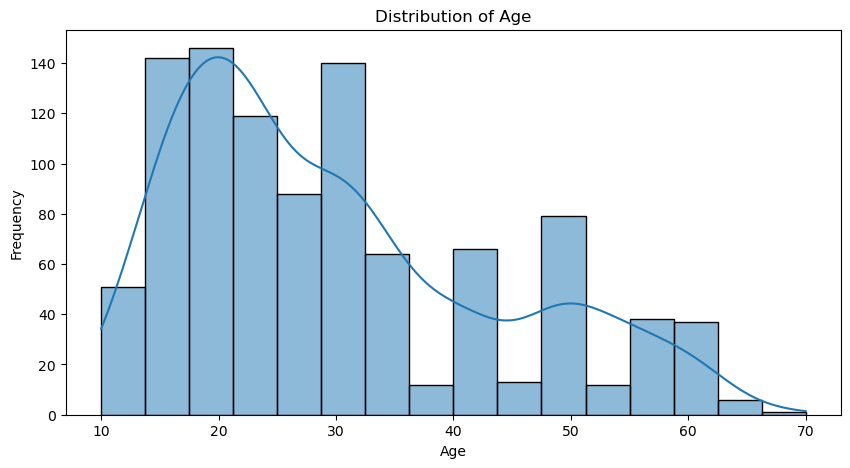

In [24]:
# Distribution of age
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Age', kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [25]:
kurtosis = df['Age'].kurt()
skewness =  df['Age'].skew()

print('Kurtosis:', kurtosis)
print('Skewness:', skewness)

Kurtosis: -0.3914143023811132
Skewness: 0.7830634848558812


The age distribution is slightly skewed to the right, indicating that most mothers in the dataset are younger. The data has a kurtosis of -0.39 indicating that the distribution is spread out with a few outliers.

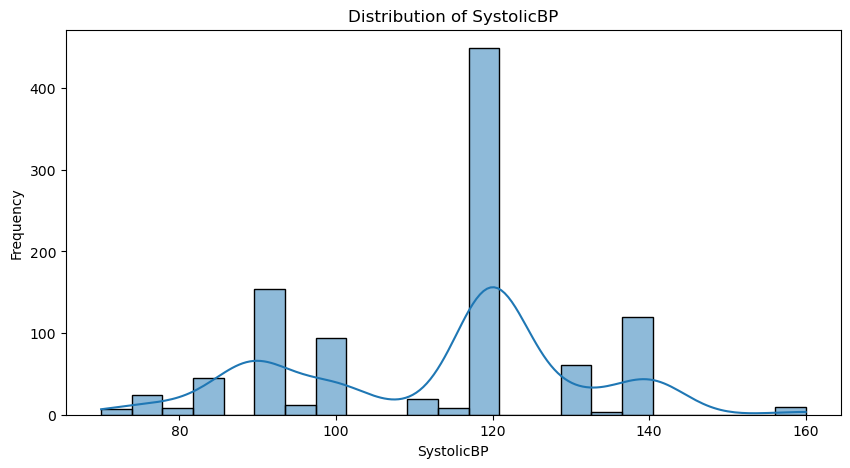

In [26]:
# Distribution of systolicBp
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='SystolicBP', kde=True)
plt.title('Distribution of SystolicBP')
plt.xlabel('SystolicBP')
plt.ylabel('Frequency')
plt.show()

In [27]:
kurtosis = df['SystolicBP'].kurt()
skewness =  df['SystolicBP'].skew()

print('Kurtosis:', kurtosis)
print('Skewness:', skewness)

Kurtosis: -0.6133822550376054
Skewness: -0.2511893119843189


The skewness value of −0.251 indicates a slightly left-skewed while the kurtosis value of −0.613 suggests the presence of fewer extreme outliers.

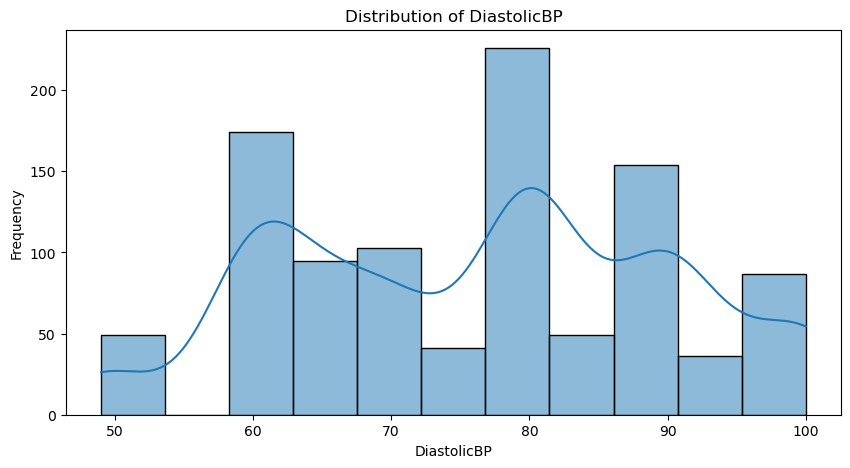

In [28]:
# Distribution of DiastolicBp 
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='DiastolicBP', kde=True)
plt.title('Distribution of DiastolicBP')
plt.xlabel('DiastolicBP')
plt.ylabel('Frequency')
plt.show()

In [29]:
kurtosis = df['DiastolicBP'].kurt()
skewness =  df['DiastolicBP'].skew()

print('Kurtosis:', kurtosis)
print('Skewness:', skewness)

Kurtosis: -0.948634444683182
Skewness: -0.048440762689906526


The values are evenly distributed around the mean, with no strong skewness, while the kurtosis value of −0.948 suggests the presence of fewer extreme outliers.

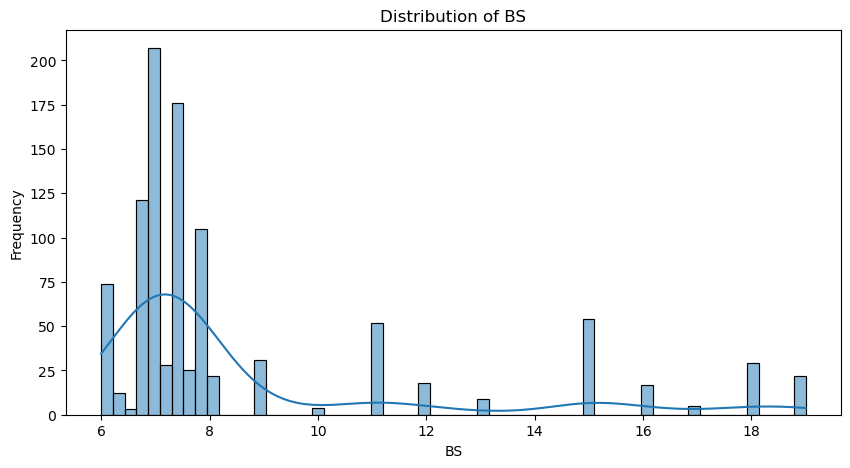

In [30]:
# Distribution of Blood sugar 
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='BS', kde=True)
plt.title('Distribution of BS')
plt.xlabel('BS')
plt.ylabel('Frequency')
plt.show()

In [31]:
kurtosis = df['BS'].kurt()
skewness =  df['BS'].skew()

print('Kurtosis:', kurtosis)
print('Skewness:', skewness)

Kurtosis: 2.303174073711283
Skewness: 1.8682026686175632


A skewness value of 1.868 indicates a strongly right-skewed distribution where most observations are concentrated at lower values while the kurtosis value of 2.303 indicates that the distribution has more extreme values.

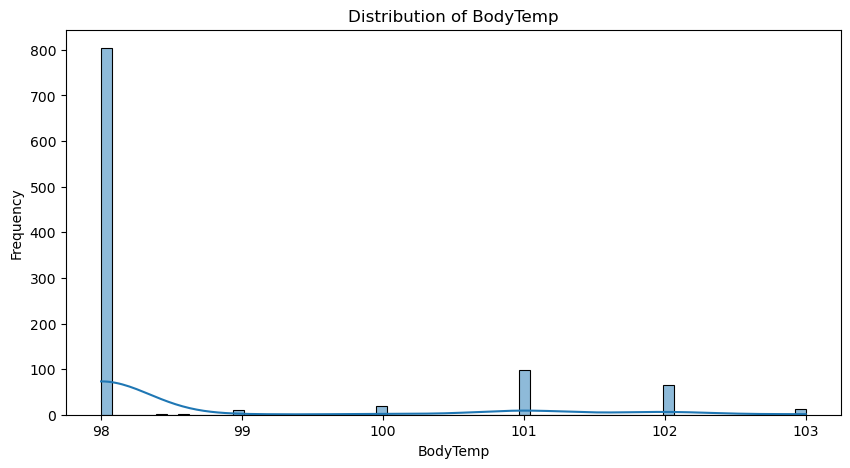

In [32]:
# Distribution of Body temperature
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='BodyTemp', kde=True)
plt.title('Distribution of BodyTemp')
plt.xlabel('BodyTemp')
plt.ylabel('Frequency')
plt.show()

In [33]:
kurtosis = df['BodyTemp'].kurt()
skewness =  df['BodyTemp'].skew()

print('Kurtosis:', kurtosis)
print('Skewness:', skewness)

Kurtosis: 1.4516803947008579
Skewness: 1.7509884998547103


The variable exhibits a skewness value of 1.751, indicating a strongly right-skewed distribution where most observations occur at lower values with a long tail toward higher values while the kurtosis value of 1.452 suggests a higher likelihood of extreme values.

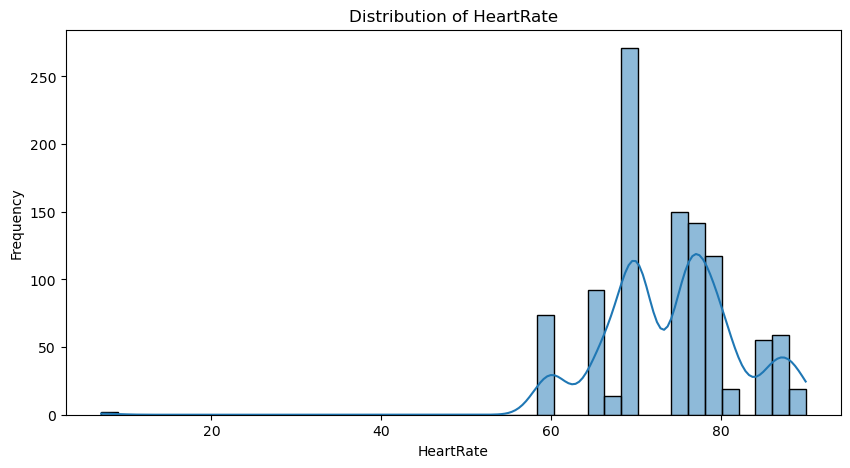

In [34]:
# Distribution of Heartrate
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='HeartRate', kde=True)
plt.title('Distribution of HeartRate')
plt.xlabel('HeartRate')
plt.ylabel('Frequency')
plt.show()

In [35]:
kurtosis = df['HeartRate'].kurt()
skewness =  df['HeartRate'].skew()

print('Kurtosis:', kurtosis)
print('Skewness:', skewness)

Kurtosis: 8.39887052484256
Skewness: -1.043525262063238


The distribution is moderately to strongly left-skewed while the value of the kurtosis indicates that the distribution has many and extreme outliers.

**(II) BOX PLOTS FOR NUMERICAL VARIABLES**

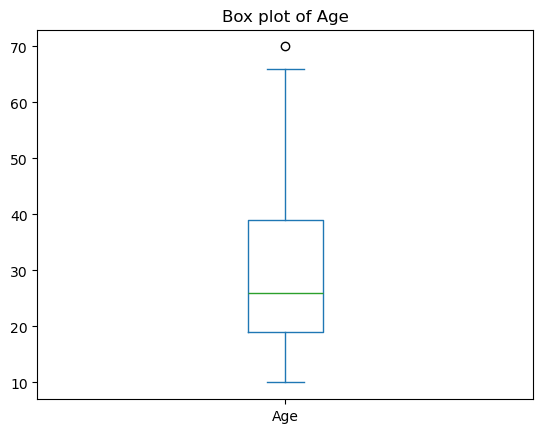

In [36]:
#Box Plot of Age (Yrs)
df['Age'].plot(kind = 'box')
plt.title ('Box plot of Age')
plt.show()

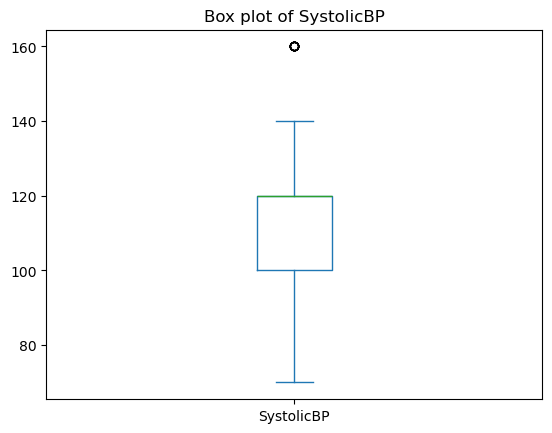

In [37]:
#Box Plot of Systolic BP
df['SystolicBP'].plot(kind = 'box')
plt.title ('Box plot of SystolicBP')
plt.show()

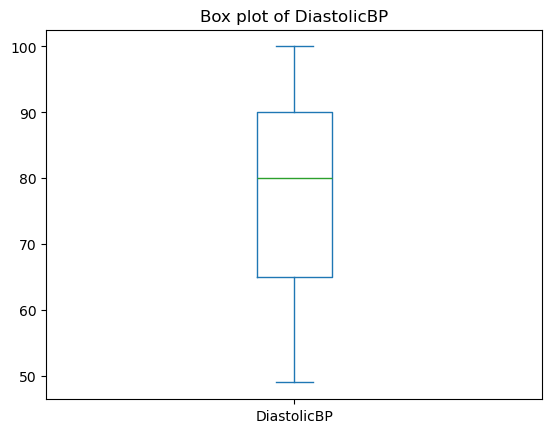

In [38]:
#Box Plot of Diastolic BP
df['DiastolicBP'].plot(kind = 'box')
plt.title ('Box plot of DiastolicBP')
plt.show()

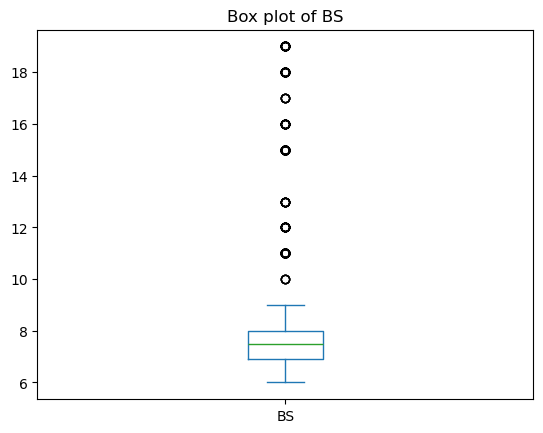

In [39]:
#Box Plot of Blood Sugar
df['BS'].plot(kind = 'box')
plt.title ('Box plot of BS')
plt.show()

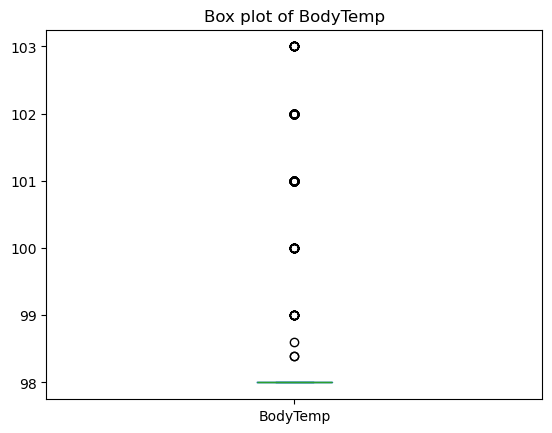

In [40]:
#Box Plot of Body Temperature
df['BodyTemp'].plot(kind = 'box')
plt.title ('Box plot of BodyTemp')
plt.show()

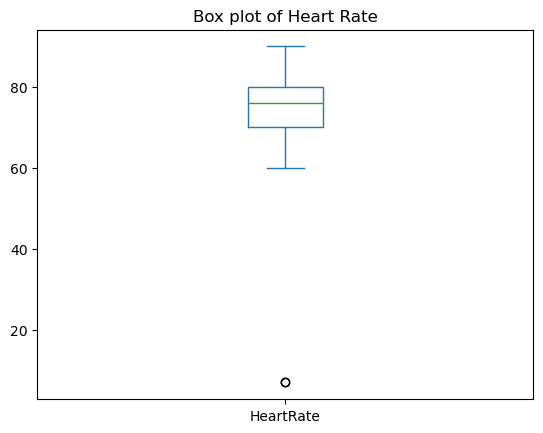

In [41]:
#Box Plot of Heart Rate
df['HeartRate'].plot(kind = 'box')
plt.title ('Box plot of Heart Rate')
plt.show()

The box plots above indicates the presence of outliers in the feature variables.
Age, SystolicBP and HeartRate have few outliers, DiastolicBP have none while Blood Sugar and Body Temperature have extremen outliers.

**(I) VALUE COUNT FOR CATEGORICAL VARIABLE**

In [42]:
plt.figure(figsize=(10,5))
counts = df["RiskLevel"].value_counts()
print(counts)

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


<Figure size 1000x500 with 0 Axes>

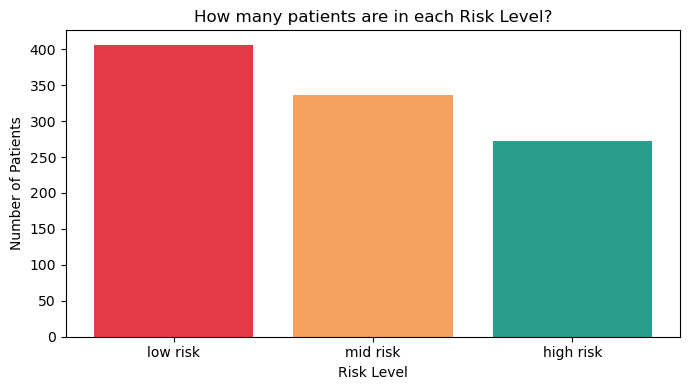

In [43]:
# Class Distribution
plt.figure(figsize=(7, 4))
counts = df['RiskLevel'].value_counts()

plt.bar(counts.index, counts.values, color=['#E63946', '#F4A261', '#2A9D8F'])
plt.title('How many patients are in each Risk Level?')
plt.xlabel('Risk Level')
plt.ylabel('Number of Patients')

plt.tight_layout()
plt.savefig('plot1_class_distribution.png', dpi=150)
plt.show()

**Percentage Breakdown**

In [44]:
#Percentage of the Distribution
Percentage_breakdown = df["RiskLevel"].value_counts(normalize=True) * 100
print(Percentage_breakdown)

RiskLevel
low risk     40.039448
mid risk     33.136095
high risk    26.824458
Name: proportion, dtype: float64


There are 406 observations in the low risk level, 336 in the mid risk level, and 272 in the high risk level.
Low risk level constitutes 40% of the dataset, mid risk level 33.1%, and high risk level constitutes 26.8%.
Also, the above countplot shows minimal differences in the number of observations across the classes, indicating a slight class imbalance. Hence, the mdoel will be built using a balanced class weight.

**BIVARIATE AND MULTIVARIATE ANALYSIS**

(I.) **Correlation matrix with heatmap**

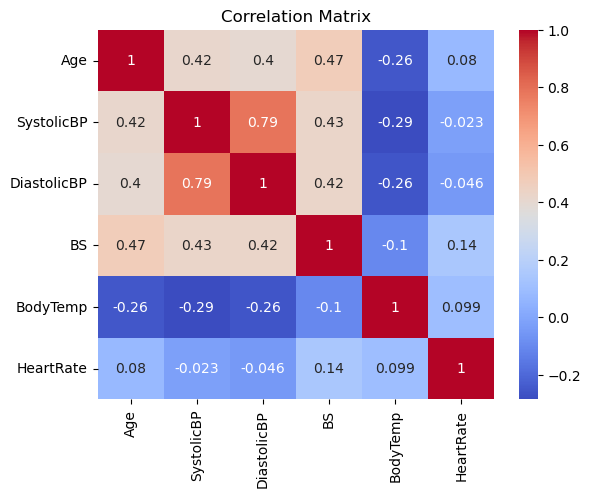

In [45]:
cols = df.select_dtypes(include = 'number').columns
correlationmatrix = df[cols].corr()


sns.heatmap(correlationmatrix, annot = True, cmap = 'coolwarm')
plt.title('Correlation Matrix')
plt.show()

The heatmap visualization shows that systolic and diastolic blood pressure have a strong positive correlation, indicating that they tend to increase together. Most other variables show weak correlations, suggesting that they contribute independent information to the dataset.

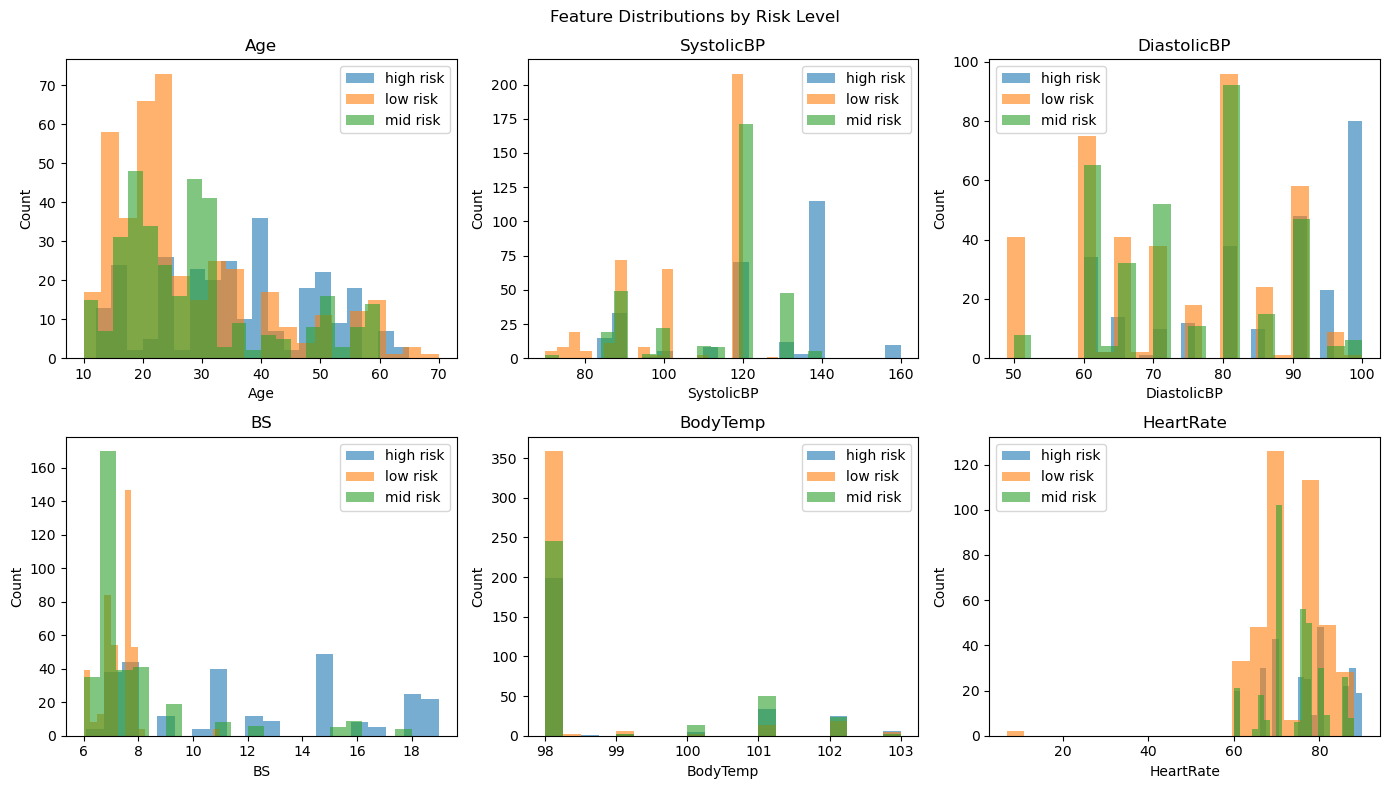

In [46]:
# Feature Distributions in relation to risk level
features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Distributions by Risk Level')
axes = axes.flatten()

for i, feature in enumerate(features):
    for risk_level in df['RiskLevel'].unique():
        subset = df[df['RiskLevel'] == risk_level][feature]
        axes[i].hist(subset, bins=20, alpha=0.6, label=risk_level)

    axes[i].set_title(feature)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.tight_layout()
plt.savefig('plot2_feature_distributions.png', dpi=150)
plt.show()

In [47]:
pd.crosstab(df["RiskLevel"], df["Age"])

Age,10,12,13,14,15,16,17,18,19,20,...,54,55,56,59,60,62,63,65,66,70
RiskLevel,,,,,,,,,,,,,,,,,,,,,
high risk,0,7,3,3,0,0,24,0,2,0,...,9,17,1,0,7,0,2,1,0,0
low risk,2,15,2,0,56,10,18,8,28,11,...,0,12,0,2,13,1,0,2,1,1
mid risk,2,13,7,0,4,6,21,11,37,11,...,3,8,0,0,14,0,0,0,0,0


In [48]:
pd.crosstab(df["RiskLevel"], df["SystolicBP"])

SystolicBP,70,75,76,78,80,83,85,90,95,99,100,110,115,120,129,130,135,140,160
RiskLevel,,,,,,,,,,,,,,,,,,,
high risk,0,0,0,0,0,2,13,33,1,0,5,8,0,70,0,12,3,115,10
low risk,5,8,16,3,5,0,11,72,8,2,65,2,0,208,1,0,0,0,0
mid risk,2,0,0,0,0,0,19,49,3,0,22,9,8,171,0,48,0,5,0


In [49]:
pd.crosstab(df["RiskLevel"], df["DiastolicBP"])

DiastolicBP,49,50,60,63,65,68,69,70,75,76,80,85,89,90,95,100
RiskLevel,,,,,,,,,,,,,,,,
high risk,0,0,34,2,14,0,1,10,12,0,38,10,0,48,23,80
low risk,25,16,75,2,41,2,0,38,15,3,96,24,1,58,9,1
mid risk,0,8,65,4,32,0,0,52,11,0,92,15,0,47,4,6


In [50]:
pd.crosstab(df["RiskLevel"], df["BS"])

BS,6.0,6.1,6.3,6.4,6.5,6.6,6.7,6.8,6.9,7.0,...,9.0,10.0,11.0,12.0,13.0,15.0,16.0,17.0,18.0,19.0
RiskLevel,,,,,,,,,,,,,,,,,,,,,
high risk,0,2,2,0,0,0,0,10,8,9,...,12,4,40,12,9,49,8,5,25,22
low risk,7,32,0,8,1,2,10,37,47,29,...,0,0,4,0,0,0,0,0,0,0
mid risk,14,19,0,2,0,0,23,41,58,41,...,19,0,8,6,0,5,9,0,4,0


In [51]:
pd.crosstab(df["RiskLevel"], df["BodyTemp"])

BodyTemp,98.0,98.4,98.6,99.0,100.0,101.0,102.0,103.0
RiskLevel,,,,,,,,
high risk,199,0,1,2,5,34,25,6
low risk,359,2,0,6,2,14,18,5
mid risk,246,0,0,2,13,50,23,2


In [52]:
pd.crosstab(df["RiskLevel"], df["HeartRate"])

HeartRate,7,60,65,66,67,68,70,75,76,77,78,80,82,86,88,90
RiskLevel,,,,,,,,,,,,,,,,
high risk,0,20,0,25,5,0,43,6,20,25,9,48,0,22,30,19
low risk,2,33,2,44,2,0,126,7,55,56,2,39,10,7,21,0
mid risk,0,21,3,18,5,2,102,6,56,15,35,30,9,26,8,0


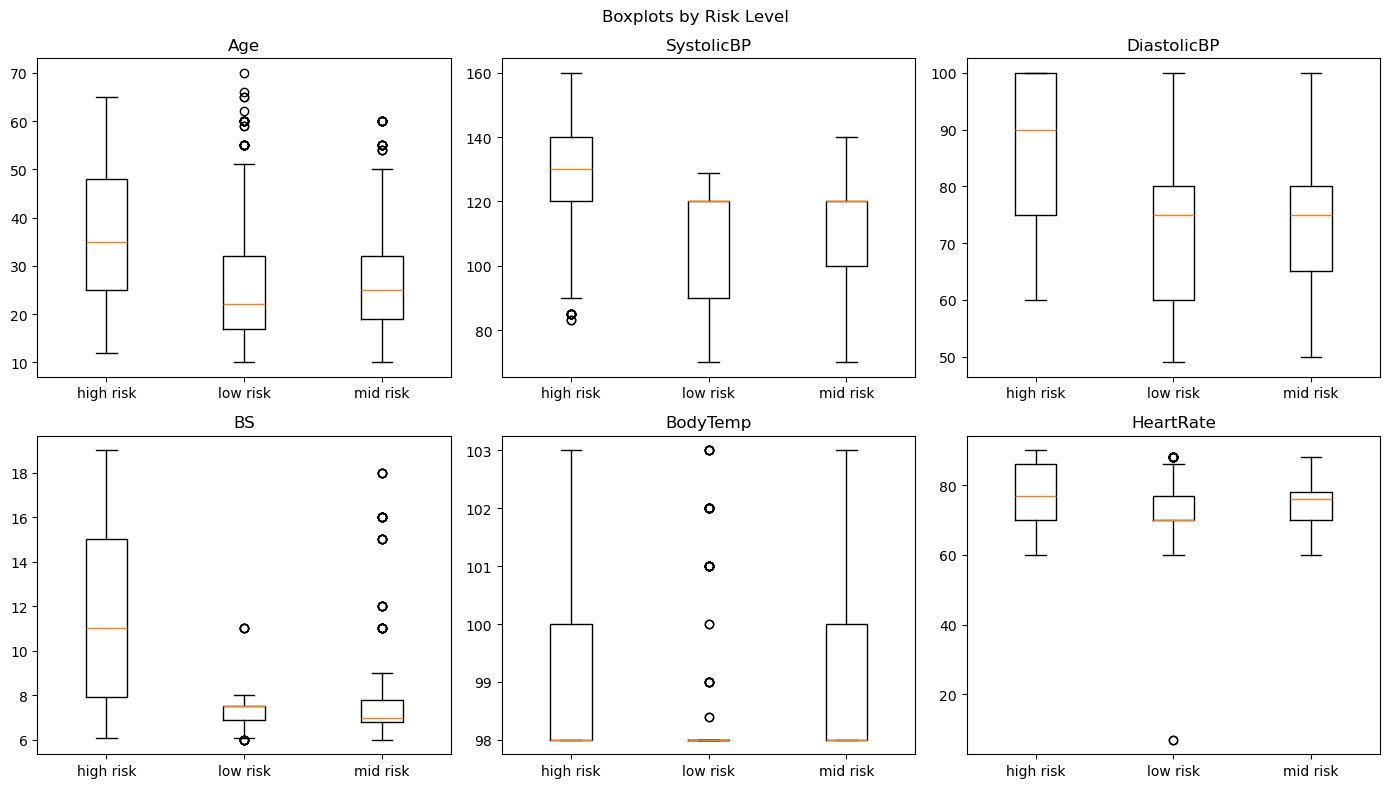

In [53]:
# Boxplots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Boxplots by Risk Level')
axes = axes.flatten()

for i, feature in enumerate(features):
    groups = [df[df['RiskLevel'] == level][feature] for level in df['RiskLevel'].unique()]
    axes[i].boxplot(groups, tick_labels=df['RiskLevel'].unique())
    axes[i].set_title(feature)

plt.tight_layout()
plt.savefig('plot4_boxplots.png', dpi=150)
plt.show()

In [54]:
# DATA CLEANING

print("Unrealistic HeartRate values (below 40):")
print(df[df['HeartRate'] < 40])

# remove those rows
df = df[df['HeartRate'] >= 40]

print("\nDataset shape after cleaning:", df.shape)

Unrealistic HeartRate values (below 40):
     Age  SystolicBP  DiastolicBP   BS  BodyTemp  HeartRate RiskLevel
499   16         120           75  7.9      98.0          7  low risk
908   16         120           75  7.9      98.0          7  low risk

Dataset shape after cleaning: (1012, 7)


**PREPROCESSING**

In [55]:
from sklearn.preprocessing import LabelEncoder
X = df.drop(columns=['RiskLevel'])
y = df['RiskLevel']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\n Label Encoding Mapping")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name} --> {i}")

class_names = le.classes_


 Label Encoding Mapping
  high risk --> 0
  low risk --> 1
  mid risk --> 2


In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size:     {X_test.shape[0]} samples")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Training set size: 809 samples
Test set size:     203 samples


**HANDLING CLASS IMBALANCE**

Class Distribution in Training Set
1    323
2    269
0    217
Name: count, dtype: int64


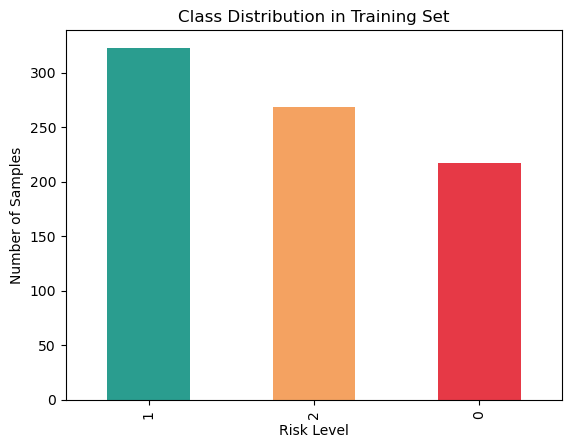

In [59]:
print("Class Distribution in Training Set")
print(pd.Series(y_train).value_counts())

pd.Series(y_train).value_counts().plot(kind='bar', color=['#2A9D8F', '#F4A261', '#E63946'])
plt.title('Class Distribution in Training Set')
plt.xlabel('Risk Level')
plt.ylabel('Number of Samples')
plt.show()

**MODEL TRAINING**

In [60]:
# Model 1: Logistic Regression (Baseline)

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr_model.fit(X_train_scaled, y_train)
print("Done!")

lr_predictions = lr_model.predict(X_test_scaled)

Done!


In [61]:
# Model 2: Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42,
    class_weight='balanced'
)
dt_model.fit(X_train, y_train)
print("Done!")

dt_predictions = dt_model.predict(X_test)

Done!


In [62]:
# Model 3: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Done!")

rf_predictions = rf_model.predict(X_test)

Done!


**MODEL EVALUATION**

In [63]:
def evaluate_model(model_name, y_true, y_pred):
    print(f"\nResults for: {model_name}")
    print("-" * 40)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"Accuracy  : {acc:.2f}")
    print(f"Precision : {prec:.2f}")
    print(f"Recall    : {rec:.2f}")
    print(f"F1-Score  : {f1:.2f}")
    print("\nFull Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    return acc, prec, rec, f1

lr_acc,   lr_prec,   lr_rec,   lr_f1   = evaluate_model("Logistic Regression", y_test, lr_predictions)
dt_acc,   dt_prec,   dt_rec,   dt_f1   = evaluate_model("Decision Tree",       y_test, dt_predictions)
rf_acc,   rf_prec,   rf_rec,   rf_f1   = evaluate_model("Random Forest",       y_test, rf_predictions)


Results for: Logistic Regression
----------------------------------------
Accuracy  : 0.58
Precision : 0.56
Recall    : 0.58
F1-Score  : 0.57

Full Classification Report:
              precision    recall  f1-score   support

   high risk       0.70      0.80      0.75        55
    low risk       0.60      0.62      0.61        81
    mid risk       0.41      0.34      0.37        67

    accuracy                           0.58       203
   macro avg       0.57      0.59      0.58       203
weighted avg       0.56      0.58      0.57       203


Results for: Decision Tree
----------------------------------------
Accuracy  : 0.70
Precision : 0.70
Recall    : 0.70
F1-Score  : 0.70

Full Classification Report:
              precision    recall  f1-score   support

   high risk       0.83      0.89      0.86        55
    low risk       0.69      0.62      0.65        81
    mid risk       0.60      0.64      0.62        67

    accuracy                           0.70       203
   macro 

The output analyses the risklevels, Logistic Regression, Decision Tree, and Random Forest models based on their accuracy, precision, recall, and F1-score.

In [65]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv   = cross_val_score(lr_model,     X_train_scaled, y_train, cv=cv, scoring='f1_weighted')
dt_cv   = cross_val_score(dt_model,     X_train,        y_train, cv=cv, scoring='f1_weighted')
rf_cv   = cross_val_score(rf_model,     X_train,        y_train, cv=cv, scoring='f1_weighted')

print(f"Logistic Regression CV F1: {lr_cv.mean():.2f}")
print(f"Decision Tree CV F1:       {dt_cv.mean():.2f}")
print(f"Random Forest CV F1:       {rf_cv.mean():.2f}")

Logistic Regression CV F1: 0.60
Decision Tree CV F1:       0.70
Random Forest CV F1:       0.83


**MODEL PERFORMANCE COMPARISON**

           Model  Accuracy  Precision    Recall  F1-Score
0    LR Baseline  0.576355   0.562290  0.576355  0.567314
1  Decision Tree  0.699507   0.699221  0.699507  0.697907
2  Random Forest  0.827586   0.828274  0.827586  0.827896


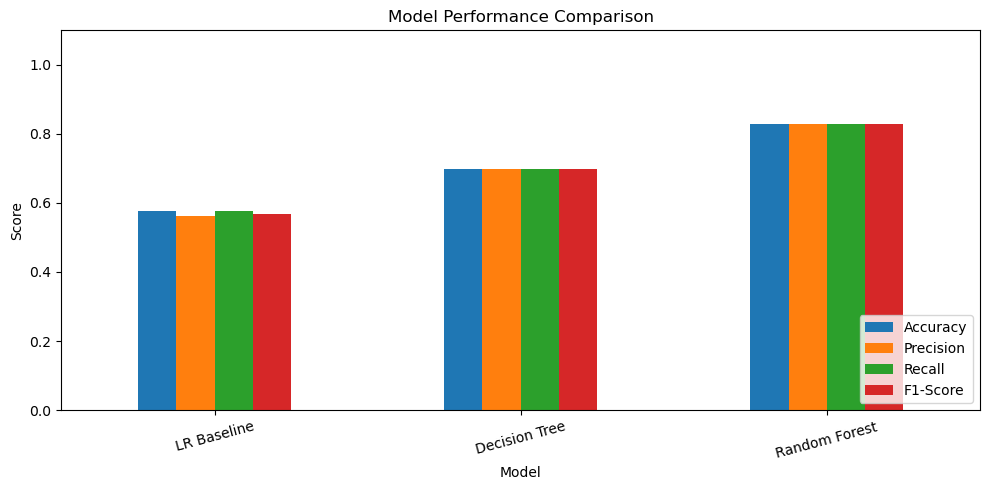

In [66]:
comparison_df = pd.DataFrame({
    'Model':     ["LR Baseline", "Decision Tree", "Random Forest"],
    'Accuracy':  [lr_acc, dt_acc,  rf_acc],
    'Precision': [lr_prec, dt_prec, rf_prec],
    'Recall':    [lr_rec, dt_rec,  rf_rec],
    'F1-Score':  [lr_f1, dt_f1,   rf_f1]
})

print(comparison_df)

comparison_df.set_index('Model').plot(kind='bar', figsize=(10, 5))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

The bars in the model comparison chart (bar chart) above show that the Random Forest model performed better than the two other models, with respect to the evaluation metrics. Decision Tree performed well, while the Logistic Regression baseline model perfomed poorly.

**FEATURE IMPORTANCE**

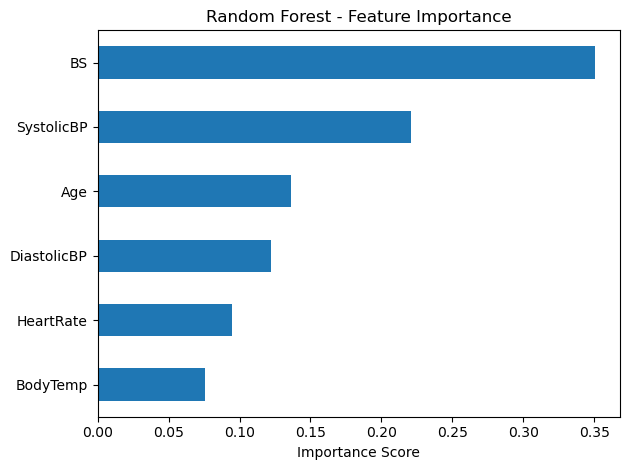

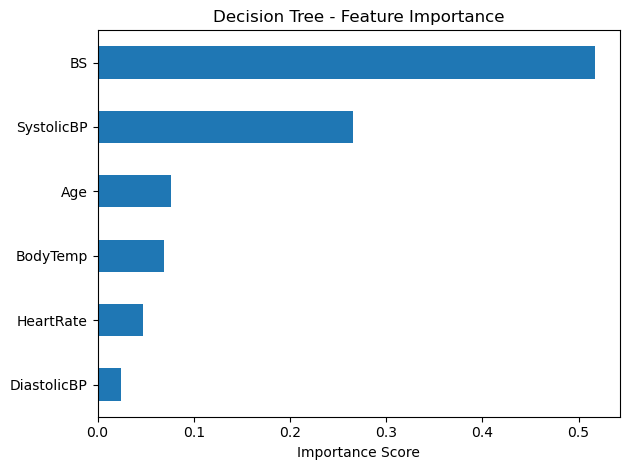

             Age  SystolicBP  DiastolicBP     BS  BodyTemp  HeartRate
high risk -0.144       0.488        0.416  1.145     0.618      0.300
low risk   0.100      -0.819        0.041 -1.129    -0.656     -0.228
mid risk   0.043       0.331       -0.458 -0.017     0.038     -0.072


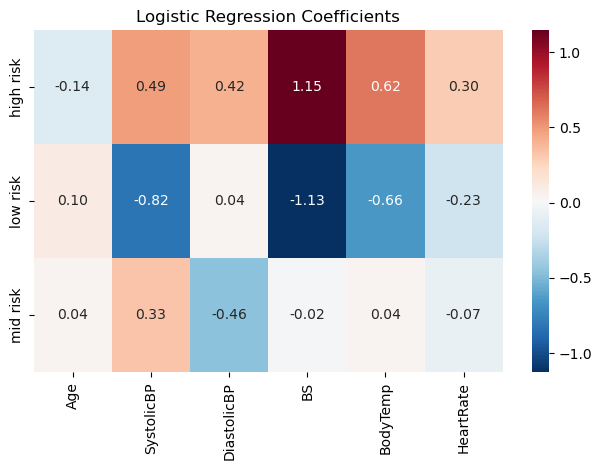

In [67]:
# Random Forest Feature Importance
rf_importances = pd.Series(rf_model.feature_importances_, index=features)
rf_importances.sort_values().plot(kind='barh')
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Decision Tree Feature Importance
dt_importances = pd.Series(dt_model.feature_importances_, index=features)
dt_importances.sort_values().plot(kind='barh')
plt.title('Decision Tree - Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Logistic Regression Coefficients
lr_coef_df = pd.DataFrame(lr_model.coef_, columns=features, index=class_names)
print(lr_coef_df.round(3))

sns.heatmap(lr_coef_df, annot=True, fmt='.2f', cmap='RdBu_r')
plt.title('Logistic Regression Coefficients')
plt.tight_layout()
plt.show()

This analysis identifies which health features most influence the prediction of maternal RiskLevel using three models: Random Forest, Decision Tree, and Logistic Regression. The features varaibles are Age, SystolicBP, DiastolicBP, Blood Sugar (BS), Body Temperature, and Heart Rate.

Random Forest and Decision Tree feature importance plots show that Blood Sugar (BS) is the most significant feature in predicting maternal health risk. This means the models rely heavily on BS values when determining whether a pregnancy falls into low, mid, or high risk. Blood pressure measurements (SystolicBP and DiastolicBP) and Body Temperature also contribute significantly, while Age and Heart Rate have smaller influence on the predictions.

The Logistic Regression coefficients gave insight into how each feature affects the probability of each risk class. For high-risk pregnancies, Blood Sugar (1.145) has the strongest positive coefficient, followed by Body Temperature (0.618), SystolicBP (0.488), and DiastolicBP (0.416). This indicates that higher values of these variables increase the likelihood of a high-risk classification. Conversely, the low-risk class has strong negative coefficients for Blood Sugar (-1.129), SystolicBP (-0.819), and Body Temperature (-0.656), meaning lower values of these indicators are associated with safer pregnancies. The mid-risk class shows smaller coefficients, suggesting it lies between low and high risk conditions and is therefore harder for the model to clearly distinguish.

**ERROR ANALYSIS**

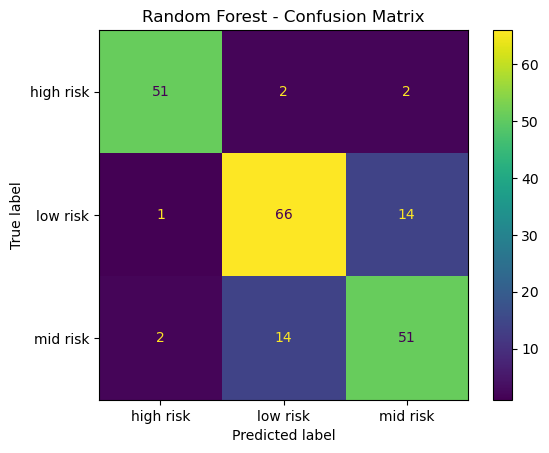

In [68]:
# confusion matrix for the best model (random forest)
cm_rf = confusion_matrix(y_test, rf_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=class_names)
disp.plot()
plt.title('Random Forest - Confusion Matrix')
plt.show()

Correctly classified:   168
Misclassified:          35

Error Breakdown (True vs Predicted):
Predicted_Label  high risk  low risk  mid risk
True_Label                                    
high risk                0         2         2
low risk                 1         0        14
mid risk                 2        14         0


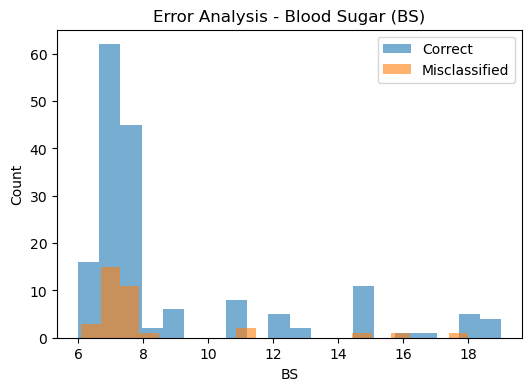

In [69]:
# Using Blood suger(BS) for error analysis since it is the most important feature

error_df = X_test.copy()
error_df['True_Label']      = [class_names[i] for i in y_test]
error_df['Predicted_Label'] = [class_names[i] for i in rf_predictions]
error_df['Correct']         = error_df['True_Label'] == error_df['Predicted_Label']

print("Correctly classified:  ", error_df['Correct'].sum())
print("Misclassified:         ", (~error_df['Correct']).sum())

misclassified = error_df[error_df['Correct'] == False]
print("\nError Breakdown (True vs Predicted):")
print(pd.crosstab(misclassified['True_Label'], misclassified['Predicted_Label']))

correct_df = error_df[error_df['Correct'] == True]
wrong_df   = error_df[error_df['Correct'] == False]

plt.figure(figsize=(6, 4))
plt.hist(correct_df['BS'], bins=20, alpha=0.6, label='Correct')
plt.hist(wrong_df['BS'],   bins=20, alpha=0.6, label='Misclassified')
plt.title('Error Analysis - Blood Sugar (BS)')
plt.xlabel('BS')
plt.ylabel('Count')
plt.legend()
plt.show()

From the analysis above, the model predicted 168 cases correctly  and 35 cases incorrectly. The analyses focused on Blood Sugar (BS) because it was identified as the most important feature influencing maternal health risk. Most errors occur between low risk and mid risk categories. In the histogram, there were overlaps between the Blood Sugar values across different risk levels, which seems to be the reason for the error.

In [70]:
# SUMMARY TABLE

summary_df = pd.DataFrame({
    'Model':     ["LR Baseline", "Decision Tree", "Random Forest"],
    'Accuracy':  [lr_acc, dt_acc,  rf_acc],
    'Precision': [lr_prec, dt_prec, rf_prec],
    'Recall':    [lr_rec, dt_rec,  rf_rec],
    'F1-Score':  [lr_f1, dt_f1,   rf_f1],
    'CV F1':     [lr_cv.mean(), dt_cv.mean(), rf_cv.mean()]
})

print(summary_df)

print("\nBest model: Random Forest")
print(f"F1-Score : {rf_f1:.2f}")
print(f"CV F1    : {rf_cv.mean():.2f}")

           Model  Accuracy  Precision    Recall  F1-Score     CV F1
0    LR Baseline  0.576355   0.562290  0.576355  0.567314  0.604995
1  Decision Tree  0.699507   0.699221  0.699507  0.697907  0.699049
2  Random Forest  0.827586   0.828274  0.827586  0.827896  0.826902

Best model: Random Forest
F1-Score : 0.83
CV F1    : 0.83


The analysis compares three classification algorithms for predicting maternal health risk levels. Logistic Regression shows the lowest performance, Decision Tree performs moderately well, while Random Forest achieves the highest accuracy and F1-score.

Random Forest, with an accuracy level of 82.8%,  performed best among the three models. It correctly predicts the maternal risk level in most cases. This is because it combined multiple decision trees, thereby, capturing hidden patterns in the feature variables.

Therefore, Random Forest is the best model for the dataset, as it provides the most accurate predictions for detecting different risk levels in pregnant women.

**FINAL ANALYSIS**

To understand the variables that contribute more to predicting health risk, feature importance was extracted from the trained Random Forest classifier. Feature importance measured the contribution of each feature to the target, maternal risk levels.

From the results, Systolic Blood Pressure and blood sugar levels (BS) have higher importance scores, indicating that they play more significant roles in determining maternal health risk. 

Maternal age also contributes to maternal health risk, though insignificantly. Age-related issues in pregnancy are common with mothers that are either young or advanced in age.

Fnally, variables such as body temperature and heart rate have lower importance scores suggesting that they are less influential in contributing to maternal health risks.

**RECOMMENDATION**

In conclusion, it is highly recommended that the blood pressure and blood sugar of patients should be closely monitored during pregnancy, to prevent complications during pregnancy or even the death of the mother.